# lgbm_3class_xfn5d_30f — Training & Hyperparameter Tuning

**Purpose**: Fully self-contained notebook that:
1. Loads the dataset and defines all constants (features, target, folds)
2. Runs a walk-forward hyperparameter search over the key LightGBM parameters
3. Selects the best configuration using a composite score (ASA + F1)
4. Trains the final "production" model on all available data with the best params
5. Saves a new dated artifact — **does not overwrite** the original locked artifact

> The performance & SHAP analysis notebook (`lgbm_3class_xfn5d_30f_performance_and_shap.ipynb`)
> loads this artifact to run the 7-fold walk-forward evaluation.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
from datetime import date
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT         = NOTEBOOK_DIR.parents[1]          # project root
EXP_PARENT   = ROOT / 'step3_predictive_model/model_experiments'
ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT         : {ROOT}')
print(f'Artifact dir : {ARTIFACT_DIR}')

ROOT         : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/final_model/artifacts


## 1. Dataset & Constants

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset : {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')

Dataset : 1285 rows  |  2021-02-25 → 2026-04-09


In [3]:
# ── Load configuration from locked artifact ────────────────────────────────────
import pickle

LOCKED_PKL = sorted(ARTIFACT_DIR.glob('lgbm_3class_xfn5d_30f-*.pkl'))
assert LOCKED_PKL, 'Locked artifact not found in artifacts/ — run the original training first.'
with open(LOCKED_PKL[-1], 'rb') as f:
    locked = pickle.load(f)

FEATURES  = locked['features']
TARGET    = locked['target']
THRESHOLD = locked['threshold']
label_map = locked['label_map']
inv_map   = locked['inverse_label_map']

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing features: {missing}'

print(f'Loaded config from : {LOCKED_PKL[-1].name}')
print(f'Features           : {len(FEATURES)}')
print(f'Target             : {TARGET}')
print(f'Threshold          : ±{THRESHOLD*100:.2f}%')
print(f'Folds              : {len(E10_FOLDS)}')
print()
print('Features list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

Loaded config from : lgbm_3class_xfn5d_30f-2026-04-21.pkl
Features           : 30
Target             : target_excess_xfn_5d
Threshold          : ±0.30%
Folds              : 7

Features list:
   1. td_return_5d
   2. td_return_20d
   3. td_volatility_20d
   4. td_vs_xfn_5d
   5. td_vs_tsx_5d
   6. td_corr_pv_20d
   7. td_volume_change_20d
   8. td_dist_52w_high
   9. yield_curve_slope
  10. yield_10y_level
  11. vix_volatility_20d
  12. dxy_level
  13. gold_level
  14. fx_usdcad_level
  15. news_sent_mean_30d
  16. news_count_30d
  17. days_since_last_news
  18. days_since_call
  19. is_earnings_week
  20. evt_ceo_tone
  21. evt_cfo_tone
  22. evt_framing_gap
  23. evt_aml_pressure
  24. evt_aml_shift
  25. evt_guidance_strength
  26. evt_guidance_shift
  27. evt_macro_topic
  28. evt_topic_entropy
  29. evt_news_tone
  30. evt_news_flow


## 2. Helper Functions

In [4]:
def offset_metrics(preds, y_true_cls, y_true_cont, dates):
    """Stride-5 offset-averaged metrics.
    active_asa uses continuous excess return (signal-detector definition).
    """
    rows = []
    for off in OFFSETS:
        idx    = np.arange(off, len(dates), STRIDE)
        p      = preds[idx]
        y_cls  = y_true_cls[idx]
        y_cont = y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()


def fit_with_params(train_df, test_df, params: dict):
    """Train LightGBM with given params and return predictions + labels."""
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **params
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds_enc = clf.predict(x_te)
    preds     = np.array([inv_map[p] for p in preds_enc])
    return clf, preds, y_te_cls, y_te_cont


print('Helper functions defined.')

Helper functions defined.


## 3. Hyperparameter Search

Sweep the three parameters most sensitive to dataset size.  
All others are held at their informed defaults.

| Param | Values | Default |
|---|---|---|
| `num_leaves` | 4, 8, 16, 31 | 8 |
| `min_child_samples` | 20, 40, 60 | 40 |
| `n_estimators` | 80, 120, 200 | 120 |

**Selection criterion** (primary): composite score = `0.6 × active_asa + 0.4 × macro_f1`  
This balances directional signal quality (primary) with balanced class prediction (secondary).

In [5]:
BASE_PARAMS = dict(
    learning_rate=0.05, feature_fraction=0.8,
    reg_alpha=0.2, reg_lambda=1.0,
)

GRID = {
    'num_leaves':        [4, 8, 16, 31],
    'min_child_samples': [20, 40, 60],
    'n_estimators':      [80, 120, 200],
}

combos = list(iterproduct(
    GRID['num_leaves'], GRID['min_child_samples'], GRID['n_estimators']
))
print(f'Running {len(combos)} configs × {len(E10_FOLDS)} folds …\n')

search_rows = []
for i, (nl, mcs, ne) in enumerate(combos, 1):
    params = {**BASE_PARAMS, 'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne}
    fold_ms = []
    for fold_id, train_end, test_start, test_end in E10_FOLDS:
        tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
        te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
                   (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
        _, preds, y_cls, y_cont = fit_with_params(df[tr_mask], df[te_mask], params)
        fold_ms.append(offset_metrics(preds, y_cls, y_cont, df[te_mask]['date'].values))

    agg  = pd.DataFrame(fold_ms).mean()
    comp = 0.6 * float(agg.active_asa) + 0.4 * float(agg.macro_f1)
    search_rows.append({
        'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne,
        'mean_acc':   round(float(agg.mean_acc),   3),
        'macro_f1':   round(float(agg.macro_f1),   3),
        'active_asa': round(float(agg.active_asa),  3),
        'active_cov': round(float(agg.active_cov),  3),
        'composite':  round(comp, 4),
    })
    print(f'[{i:2d}/36]  leaves={nl:2d}  mcs={mcs:2d}  ne={ne:3d}  '
          f'asa={agg.active_asa:.3f}  f1={agg.macro_f1:.3f}  composite={comp:.4f}')

print('\nSearch complete.')

Running 36 configs × 7 folds …



[ 1/36]  leaves= 4  mcs=20  ne= 80  asa=0.603  f1=0.330  composite=0.4935


[ 2/36]  leaves= 4  mcs=20  ne=120  asa=0.586  f1=0.332  composite=0.4841


[ 3/36]  leaves= 4  mcs=20  ne=200  asa=0.547  f1=0.319  composite=0.4559


[ 4/36]  leaves= 4  mcs=40  ne= 80  asa=0.580  f1=0.344  composite=0.4855


...

[32/36]  leaves=31  mcs=40  ne=120  asa=0.568  f1=0.324  composite=0.4705


[33/36]  leaves=31  mcs=40  ne=200  asa=0.559  f1=0.326  composite=0.4660


[34/36]  leaves=31  mcs=60  ne= 80  asa=0.558  f1=0.327  composite=0.4660


[35/36]  leaves=31  mcs=60  ne=120  asa=0.574  f1=0.347  composite=0.4831


[36/36]  leaves=31  mcs=60  ne=200  asa=0.558  f1=0.329  composite=0.4666

Search complete.


## 4. Results & Best Configuration

In [6]:
search_df = (
    pd.DataFrame(search_rows)
    .sort_values('composite', ascending=False)
    .reset_index(drop=True)
)
search_df.index += 1

print('=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===\n')
display(search_df[['num_leaves','min_child_samples','n_estimators',
                    'active_asa','macro_f1','mean_acc','active_cov','composite']])

best_row  = search_df.iloc[0]
BEST_PARAMS = {
    **BASE_PARAMS,
    'num_leaves':        int(best_row.num_leaves),
    'min_child_samples': int(best_row.min_child_samples),
    'n_estimators':      int(best_row.n_estimators),
}

print(f'\n── Best configuration (rank 1 by composite) ──')
for k, v in BEST_PARAMS.items():
    print(f'  {k}: {v}')
print(f'\n  ASA       : {best_row.active_asa:.3f}')
print(f'  Macro F1  : {best_row.macro_f1:.3f}')
print(f'  Mean acc  : {best_row.mean_acc:.3f}')
print(f'  Composite : {best_row.composite:.4f}')

=== Search results (sorted by composite score = 0.6×ASA + 0.4×F1) ===



,num_leaves,min_child_samples,n_estimators,active_asa,macro_f1,mean_acc,active_cov,composite
1,8,40,120,0.600,0.359,0.468,0.943,0.5036
2,8,40,80,0.600,0.353,0.481,0.964,0.5009
3,4,20,80,0.603,0.330,0.485,0.967,0.4935
4,4,40,200,0.588,0.345,0.464,0.937,0.4909
5,4,40,120,0.588,0.342,0.470,0.956,0.4897
6,8,60,200,0.579,0.351,0.452,0.931,0.4882
7,4,40,80,0.580,0.344,0.468,0.970,0.4855
8,4,20,120,0.586,0.332,0.472,0.944,0.4841
9,31,60,120,0.574,0.347,0.454,0.946,0.4831
10,8,60,120,0.574,0.345,0.448,0.932,0.4821



── Best configuration (rank 1 by composite) ──
  learning_rate: 0.05
  feature_fraction: 0.8
  reg_alpha: 0.2
  reg_lambda: 1.0
  num_leaves: 8
  min_child_samples: 40
  n_estimators: 120

  ASA       : 0.600
  Macro F1  : 0.359
  Mean acc  : 0.468
  Composite : 0.5036


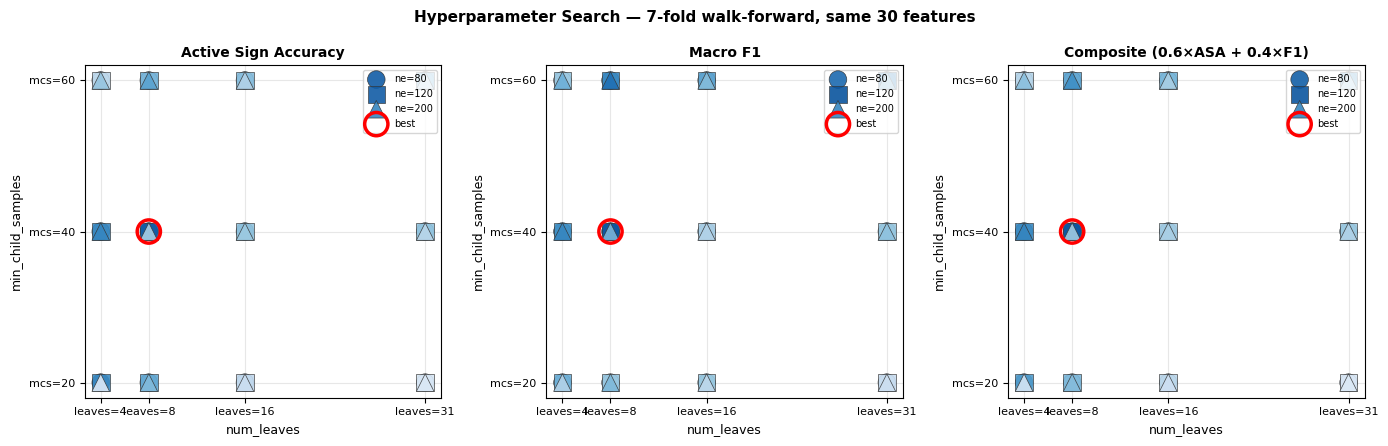

In [7]:
# ── Bubble chart: composite score across the grid ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ne_vals  = GRID['n_estimators']
colors   = ['#4a7cf6', '#f0a500', '#e55a5a']
markers  = ['o', 's', '^']

for ax, (metric, label) in zip(axes, [
    ('active_asa', 'Active Sign Accuracy'),
    ('macro_f1',   'Macro F1'),
    ('composite',  'Composite (0.6×ASA + 0.4×F1)'),
]):
    for ne, color, marker in zip(ne_vals, colors, markers):
        sub = search_df[search_df.n_estimators == ne]
        ax.scatter(sub.num_leaves, sub.min_child_samples,
                   s=160, c=sub[metric], cmap='Blues',
                   vmin=search_df[metric].min()-0.01,
                   vmax=search_df[metric].max()+0.01,
                   marker=marker, edgecolors='#333', linewidths=0.5,
                   label=f'ne={ne}', alpha=0.9, zorder=3)

    # highlight best
    ax.scatter(int(best_row.num_leaves), int(best_row.min_child_samples),
               s=280, c='none', edgecolors='red', linewidths=2.5,
               zorder=4, label='best')

    ax.set_xticks(GRID['num_leaves'])
    ax.set_xticklabels([f'leaves={v}' for v in GRID['num_leaves']], fontsize=8)
    ax.set_yticks(GRID['min_child_samples'])
    ax.set_yticklabels([f'mcs={v}' for v in GRID['min_child_samples']], fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('num_leaves', fontsize=9)
    ax.set_ylabel('min_child_samples', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Search — 7-fold walk-forward, same 30 features',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train Final Model & Save Artifact

Train on **all available data** (the full dataset up to the last available date)
using the best hyperparameters. This is the "production" model — the one you
would use to generate forward-looking signals on new data.

The 7-fold walk-forward evaluation (done in the performance notebook) uses the
same hyperparameters but trains each fold incrementally to avoid look-ahead.

In [8]:
# ── Train on all available non-null target rows ───────────────────────────────
full_df    = df[df[TARGET].notna()].copy()
train_end  = full_df['date'].max()

x_full = full_df[FEATURES].fillna(full_df[FEATURES].median())
y_full = label_3class(full_df[TARGET].values, threshold=THRESHOLD)
y_enc  = np.array([label_map[v] for v in y_full], dtype=int)

final_clf = lgb.LGBMClassifier(
    objective='multiclass', num_class=3,
    random_state=42, verbose=-1, n_jobs=1,
    **BEST_PARAMS,
)
final_clf.fit(x_full, y_enc)

print(f'Trained on : {len(full_df)} rows')
print(f'Date range : {full_df["date"].min().date()} → {train_end.date()}')
print(f'Params     : {BEST_PARAMS}')
print('Training complete ✓')

Trained on : 1285 rows
Date range : 2021-02-25 → 2026-04-09
Params     : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 8, 'min_child_samples': 40, 'n_estimators': 120}
Training complete ✓


## 6. Save Artifact

In [9]:
TODAY       = date.today().isoformat()     # e.g. 2026-04-22
ARTIFACT_ID = f'lgbm_3class_xfn5d_30f_tuned-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

# ── PKL ───────────────────────────────────────────────────────────────────────
artifact = {
    'model':              final_clf,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          label_map,
    'inverse_label_map':  inv_map,
    'best_params':        BEST_PARAMS,
    'train_rows':         len(full_df),
    'train_end':          str(train_end.date()),
    'artifact_id':        ARTIFACT_ID,
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

# ── JSON metadata ─────────────────────────────────────────────────────────────
meta = {
    'artifact_id':     ARTIFACT_ID,
    'model_name':      'lgbm_3class_xfn5d_30f',
    'artifact_type':   'tuned',
    'created':         TODAY,
    'source':          'lgbm_3class_xfn5d_30f_training.ipynb',
    'description':     (
        'LightGBM 3-class signal model (outperform / neutral / underperform vs XFN). '
        'Hyperparameters selected via 36-config × 7-fold walk-forward search, '
        'composite score = 0.6×ASA + 0.4×F1. '
        'Production model trained on all available data.'
    ),
    'best_params':     BEST_PARAMS,
    'search_winner':   {
        'active_asa':  float(best_row.active_asa),
        'macro_f1':    float(best_row.macro_f1),
        'composite':   float(best_row.composite),
        'rank':        1,
    },
    'features':        FEATURES,
    'n_features':      len(FEATURES),
    'target':          TARGET,
    'threshold':       THRESHOLD,
    'train_rows':      int(len(full_df)),
    'train_end':       str(train_end.date()),
    'artifact_path':   str(PKL_PATH),
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved PKL  : {PKL_PATH.name}')
print(f'Saved JSON : {JSON_PATH.name}')
print()
print('Existing artifacts in folder:')
for p in sorted(ARTIFACT_DIR.glob('*.pkl')):
    tag = '  ← original locked' if 'tuned' not in p.name else '  ← new tuned'
    print(f'  {p.name}{tag}')

Saved PKL  : lgbm_3class_xfn5d_30f_tuned-2026-04-22.pkl
Saved JSON : lgbm_3class_xfn5d_30f_tuned-2026-04-22.json

Existing artifacts in folder:
  lgbm_3class_xfn5d_30f-2026-04-21.pkl  ← original locked
  lgbm_3class_xfn5d_30f_tuned-2026-04-22.pkl  ← new tuned
